In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn import linear_model
from itertools import combinations
from sklearn.metrics import mean_squared_error

df = pd.read_csv("prostate.csv")

train = df[df["train"] == "T"]
test = df[df["train"] == "F"]

x_train = train[["lcavol", "lweight", "age", "lbph", "svi", "lcp", "gleason", "pgg45"]]
y_train = train["lpsa"]
x_test = test[["lcavol", "lweight", "age", "lbph", "svi", "lcp", "gleason", "pgg45"]]
y_test = test["lpsa"]

3a) Standard Linear Regression Model using OLS

In [11]:
linear_regression = linear_model.LinearRegression()
linear_regression.fit(x_train, y_train)

lr = sm.OLS(y_train, x_train)
results = lr.fit()
print(results.summary())

# R^2
print("R^2: ", results.rsquared)

# P-values
print("P-values: ", results.pvalues)

# Significant predictors using 0.05 significance level
significant_predictors = results.pvalues[results.pvalues < 0.05]
print("Significant predictors: ", significant_predictors)

# Training and Testing Errors
train_predictions = linear_regression.predict(x_train)
test_predictions = linear_regression.predict(x_test)
train_error = np.mean((y_train - train_predictions) ** 2)
test_error = np.mean((y_test - test_predictions) ** 2)
print("Training Error: ", train_error)
print("Testing Error: ", test_error)

                                 OLS Regression Results                                
Dep. Variable:                   lpsa   R-squared (uncentered):                   0.941
Model:                            OLS   Adj. R-squared (uncentered):              0.933
Method:                 Least Squares   F-statistic:                              117.6
Date:                Sat, 29 Mar 2025   Prob (F-statistic):                    2.43e-33
Time:                        22:12:28   Log-Likelihood:                         -67.549
No. Observations:                  67   AIC:                                      151.1
Df Residuals:                      59   BIC:                                      168.7
Df Model:                           8                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

3b) AIC Value vs Degree of Freedom graph

[('lcavol',), ('lweight',), ('age',), ('lbph',), ('svi',), ('lcp',), ('gleason',), ('pgg45',)]
[-25.37360907803762, 8.307136075706351, 22.72785489476331, 21.49302680482578, 1.4198986280740475, 7.9657329011922124, 17.9367573234735, 11.279855240166084]
[('lcavol', 'lweight'), ('lcavol', 'age'), ('lcavol', 'lbph'), ('lcavol', 'svi'), ('lcavol', 'lcp'), ('lcavol', 'gleason'), ('lcavol', 'pgg45'), ('lweight', 'age'), ('lweight', 'lbph'), ('lweight', 'svi'), ('lweight', 'lcp'), ('lweight', 'gleason'), ('lweight', 'pgg45'), ('age', 'lbph'), ('age', 'svi'), ('age', 'lcp'), ('age', 'gleason'), ('age', 'pgg45'), ('lbph', 'svi'), ('lbph', 'lcp'), ('lbph', 'gleason'), ('lbph', 'pgg45'), ('svi', 'lcp'), ('svi', 'gleason'), ('svi', 'pgg45'), ('lcp', 'gleason'), ('lcp', 'pgg45'), ('gleason', 'pgg45')]
[-35.61679636983291, -23.423191382069184, -30.572373525421185, -26.793741116709395, -23.465477831712484, -23.53103675114468, -25.057965297652668, 9.772159952599495, 10.026145404472434, -13.3502737199228

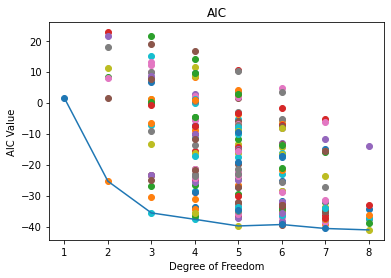

The minimum AIC values are:  [1.458809773002296, -25.37360907803762, -35.61679636983291, -37.68291356508498, -39.82507244977625, -39.364852213098764, -40.6393931650699, -41.10281207095607]
Minimum AIC value is:  -41.10281207095607
The minimum AIC value is obtained using the corresponding features:  ('lcavol', 'lweight', 'age', 'lbph', 'svi', 'lcp', 'pgg45')


In [ ]:
def AIC(train_data, train_label):
    lm = linear_model.LinearRegression().fit(train_data, train_label)
    predict_label = lm.predict(train_data)
    degree_freedom = train_data.shape[1]
    sample_size = train_data.shape[0]
    SSE = np.dot((train_label - predict_label), (train_label - predict_label))
    return sample_size * np.log(SSE / sample_size) + 2 * degree_freedom


feature_names = list(x_train.columns.values)
min_AIC = []
min_AIC.append(y_train.var())
plt.scatter(1, y_train.var())  # when there is only the intercept term, plot variance
for i in range(1, 8):
    names = list(
        combinations(feature_names, i)
    )  # generate the combination of i feature names and convert it to a list
    print(names)
    aic_list = []  # define a list to store AIC values
    for each_element in names:
        aic_list.append(
            AIC(x_train[list(each_element)], y_train)
        )  # append BIC values to the list
    min_AIC.append(np.min(aic_list))
    min_index = np.argmin(aic_list)
    print(aic_list)
    for each_value in aic_list:
        plt.scatter(x=i + 1, y=each_value)  # plot AIC values

plt.plot([1, 2, 3, 4, 5, 6, 7, 8], min_AIC)
plt.title("AIC")
plt.xlabel("Degree of Freedom")
plt.ylabel("AIC Value")
plt.show()

print("The minimum AIC values are: ", min_AIC)
print("Minimum AIC value is: ", np.min(min_AIC))
print(
    "The minimum AIC value is obtained using the corresponding features: ",
    names[min_index],
)

3c)

[('lcavol',), ('lweight',), ('age',), ('lbph',), ('svi',), ('lcp',), ('gleason',), ('pgg45',)]
[-23.168916458646656, 10.511828695097318, 24.932547514154276, 23.697719424216746, 3.6245912474650135, 10.170425520583178, 20.141449942864465, 13.48454785955705]
[('lcavol', 'lweight'), ('lcavol', 'age'), ('lcavol', 'lbph'), ('lcavol', 'svi'), ('lcavol', 'lcp'), ('lcavol', 'gleason'), ('lcavol', 'pgg45'), ('lweight', 'age'), ('lweight', 'lbph'), ('lweight', 'svi'), ('lweight', 'lcp'), ('lweight', 'gleason'), ('lweight', 'pgg45'), ('age', 'lbph'), ('age', 'svi'), ('age', 'lcp'), ('age', 'gleason'), ('age', 'pgg45'), ('lbph', 'svi'), ('lbph', 'lcp'), ('lbph', 'gleason'), ('lbph', 'pgg45'), ('svi', 'lcp'), ('svi', 'gleason'), ('svi', 'pgg45'), ('lcp', 'gleason'), ('lcp', 'pgg45'), ('gleason', 'pgg45')]
[-31.207411131050982, -19.013806143287255, -26.162988286639255, -22.38435587792746, -19.056092592930554, -19.121651512362746, -20.648580058870735, 14.181545191381428, 14.435530643254364, -8.9408884

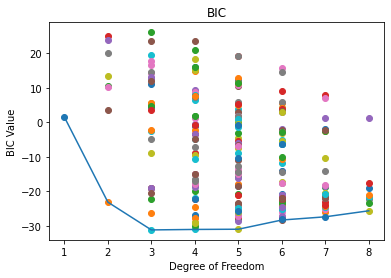

The minimum BIC values are:  [1.458809773002296, -23.168916458646656, -31.207411131050982, -31.068835706912083, -31.006301972212388, -28.341389116143937, -27.4112374487241, -25.66996373521931]
Minimum BIC value is:  -31.207411131050982
The minimum BIC value is obtained using the corresponding features:  ('lcavol', 'lweight', 'age', 'lbph', 'svi', 'lcp', 'pgg45')


In [21]:
def BIC(train_data, train_label):
    lm = linear_model.LinearRegression().fit(train_data, train_label)
    predict_label = lm.predict(train_data)
    degree_freedom = train_data.shape[1]
    sample_size = train_data.shape[0]
    SSE = np.dot((train_label - predict_label), (train_label - predict_label))
    return (
        sample_size * np.log(SSE / sample_size) + np.log(sample_size) * degree_freedom
    )


feature_names = list(x_train.columns.values)
min_BIC = []
min_BIC.append(y_train.var())
plt.scatter(1, y_train.var())  # when there is only the intercept term, plot variance
for i in range(1, 8):
    names = list(
        combinations(feature_names, i)
    )  # generate the combination of i feature names and convert it to a list
    print(names)
    bic_list = []  # define a list to store BIC values
    for each_element in names:
        bic_list.append(
            BIC(x_train[list(each_element)], y_train)
        )  # append BIC values to the list
    print(bic_list)
    min_BIC.append(np.min(bic_list))
    for each_value in bic_list:
        plt.scatter(x=i + 1, y=each_value)  # plot BIC values
plt.plot([1, 2, 3, 4, 5, 6, 7, 8], min_BIC)
plt.title("BIC")
plt.xlabel("Degree of Freedom")
plt.ylabel("BIC Value")
plt.show()

print("The minimum BIC values are: ", min_BIC)
print("Minimum BIC value is: ", np.min(min_BIC))
print(
    "The minimum BIC value is obtained using the corresponding features: ",
    names[min_index],
)